In [1]:
import pandas as pd

In [2]:
import transformers

In [3]:
import torch
import os

In [4]:
MODEL = "OLMo-2-0425-1B-Instruct-math-lora-gas8-bs16-mezo-v_proj-2560_largest_grad-5steps-seed0"

In [5]:
indices_dir = os.path.join("./models", MODEL, "indices")
indices = [
    (*f.split("_")[:-1], torch.load(os.path.join(indices_dir, f)))
    for f in os.listdir(indices_dir)
    if os.path.isfile(os.path.join(indices_dir, f)) and f.endswith((".pt"))
]
indices = [(int(i.replace("iter","")),t, ind) for i,t, ind in indices]
df = pd.DataFrame(indices, columns=["interation", "subset", "indices"])
df

,interation,subset,indices
0,7,sampling,"[135151, 169150, 85833, 202351, 165146, 206182..."
1,15,full,"[92010, 108828, 241799, 77454, 61321, 169666, ..."
2,31,sampling,"[150200, 8008, 243135, 70928, 211005, 52004, 1..."
3,31,full,"[150200, 8008, 68360, 243135, 70928, 211005, 5..."
4,23,sampling,"[214585, 40518, 106168, 241034, 218361, 244610..."
5,15,selected,"[241799, 61321, 130210, 58545, 146548, 19853, ..."
6,23,selected,"[88251, 248004, 218361, 255181, 73153, 195536,..."
7,39,selected,"[141579, 35239, 62620, 10802, 89763, 107627, 2..."
8,7,selected,"[44156, 202351, 133100, 237863, 49925, 73450, ..."
9,31,selected,"[68360, 243135, 112382, 77073, 65283, 106767, ..."


In [6]:
import pandas as pd

grouped = df.groupby('interation')


results = []

for iteration, group in grouped:
    sampling = group[group['subset'] == 'sampling']['indices']
    full = group[group['subset'] == 'full']['indices']
    selected = group[group['subset'] == 'selected']['indices']
    
    sampling_set = set(sampling.iloc[0]) if not sampling.empty else set()
    full_set = set(full.iloc[0]) if not full.empty else set()
    selected_set = set(selected.iloc[0]) if not selected.empty else set()

    selected_in_sampling = selected_set.issubset(sampling_set) if selected_set else None
    sampling_in_full = sampling_set.issubset(full_set) if sampling_set else None
    selected_in_full = selected_set.issubset(full_set) if selected_set else None
    results.append({
        'interation': iteration,
        'selected_in_sampling': selected_in_sampling,
        'sampling_in_full': sampling_in_full,
        'selected_in_full':selected_in_full
    })


results_df = pd.DataFrame(results)
print(results_df)
assert all(results_df["selected_in_full"])
assert all(results_df["sampling_in_full"])
assert not all(results_df["selected_in_sampling"])

   interation  selected_in_sampling  sampling_in_full  selected_in_full
0           7                 False              True              True
1          15                 False              True              True
2          23                 False              True              True
3          31                 False              True              True
4          39                 False              True              True


In [7]:
df["indices_len"] = df["indices"].apply(lambda x: len(x))

In [8]:
df.groupby("subset")["indices_len"].describe()

,count,mean,std,min,25%,50%,75%,max
subset,,,,,,,,
full,5.0,128.0,0.0,128.0,128.0,128.0,128.0,128.0
sampling,5.0,92.0,4.0,87.0,89.0,93.0,94.0,97.0
selected,5.0,64.0,0.0,64.0,64.0,64.0,64.0,64.0


subset
full        Axes(0.125,0.11;0.775x0.77)
sampling    Axes(0.125,0.11;0.775x0.77)
selected    Axes(0.125,0.11;0.775x0.77)
Name: indices_len, dtype: object

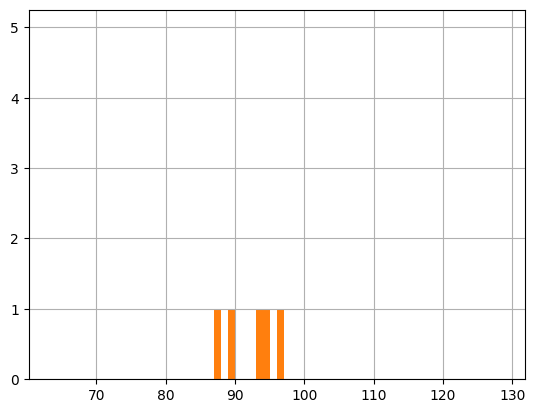

In [9]:
df.groupby("subset")["indices_len"].hist()

In [30]:
test_inputs_tuple

(tensor([[  101,  1045,  2293, 16596,  1011, 10882,  1998,  2572,  5627,  2000,
           2404,  2039,  2007,  1037,  2843,  1012, 16596,  1011, 10882,  5691,
           1013,  2694,  2024,  2788,  2104, 11263, 25848,  1010,  2104,  1011,
          12315,  1998, 28947,  1012,  1045,  2699,  2000,  2066,  2023,  1010,
           1045,  2428,  2106,  1010,  2021,  2009,  2003,  2000,  2204,  2694,
          16596,  1011, 10882,  2004, 17690,  1019,  2003,  2000,  2732, 10313,
           1006,  1996,  2434,  1007,  1012, 10021,  4013,  3367, 20086,  2015,
           1010, 10036, 19747,  4520,  1010, 25931,  3064, 22580,  1010,  1039,
           2290,  2008,  2987,  1005,  1056,  2674,  1996,  4281,  1010,  1998,
          16267,  2028,  1011,  8789,  3494,  3685,  2022,  9462,  2007,  1037,
           1005, 16596,  1011, 10882,  1005,  4292,  1012,  1006,  1045,  1005,
           1049,  2469,  2045,  2024,  2216,  1997,  2017,  2041,  2045,  2040,
           2228, 17690,  1019,  2003,  2

TypeError: The inputs given to jacobian must be either a Tensor or a tuple of Tensors but the given inputs has type <class 'transformers.modeling_outputs.CausalLMOutputWithPast'>.